In [ ]:
!pip install pandas tqdm

In [ ]:
import pandas as pd
import re

from collections import Counter
from tqdm import tqdm

In [ ]:
df = pd.read_csv("youtube_comments_BERTtopics.csv")

In [ ]:
df.head()
print(df.shape)

(24590, 15)


In [ ]:
# STEP 1: DEFINE ENTITY LISTS
# Two manually curated lists cover the domain:
# - 16 brand names (Sony, Samsung, Apple, Garmin, etc.)
# - 19 product/model names (XM5, XM6, iPhone, Galaxy, Apple Watch, etc.)
# These were chosen based on the tech review videos scraped.
brands = [
    "apple",
    "samsung",
    "sony",
    "google",
    "garmin",
    "xiaomi",
    "oppo",
    "vivo",
    "oneplus",
    "bose",
    "sennheiser",
    "nothing",
    "huawei",
    "honor",
    "motorola",
    "asus"
]

products = [
    "iphone",
    "airpods",
    "apple watch",
    "galaxy",
    "pixel",
    "xm3",
    "xm4",
    "xm5",
    "xm6",
    "redmi",
    "poco",
    "cmf",
    "redmagic",
    "s24 ultra",
    "s25 ultra",
    "find x8 pro",
    "find x9 pro",
    "vivo x200 pro",
    "vivo x300 pro"
]

In [ ]:
# STEP 2: COUNT ENTITY MENTIONS WITH REGEX
# For each comment, we use re.search() with word boundary anchors (\b)
# to check for each brand and product name.
# Word boundaries prevent partial matches — e.g. "sony" won't match "sonyxm6" as separate entities.
# Counts are accumulated using collections.Counter across all 24,590 comments.
brand_counter = Counter()
product_counter = Counter()

for text in tqdm(df["clean_text"].dropna()):

    text = str(text).lower()

    for brand in brands:
        if re.search(r"\b" + re.escape(brand) + r"\b", text):
            brand_counter[brand] += 1

    for product in products:
        if re.search(r"\b" + re.escape(product) + r"\b", text):
            product_counter[product] += 1

100%|██████████| 24590/24590 [00:03<00:00, 7754.35it/s]


In [ ]:
# STEP 3: BUILD AND DISPLAY ENTITY DATAFRAMES
# Brand and product counts are converted to dataframes and sorted by mention count.
# Vivo leads with 1,811 mentions, followed by Samsung (1,762) and Apple (1,439).
# At product level, iPhone leads with 1,010 mentions.
# A bar chart shows the top 10 most mentioned brands.
brand_df = pd.DataFrame(
    brand_counter.most_common(),
    columns=["brand", "count"]
)

product_df = pd.DataFrame(
    product_counter.most_common(),
    columns=["product", "count"]
)

brand_df.head(20)

,brand,count
0,vivo,1811
1,samsung,1762
2,apple,1439
3,garmin,850
4,sony,741
5,oppo,565
6,xiaomi,442
7,huawei,419
8,honor,325
9,oneplus,319


In [ ]:
product_df.head(20)

,product,count
0,iphone,1010
1,apple watch,496
2,galaxy,417
3,xm5,386
4,vivo x200 pro,345
5,pixel,305
6,xm4,292
7,xm6,257
8,airpods,212
9,poco,187


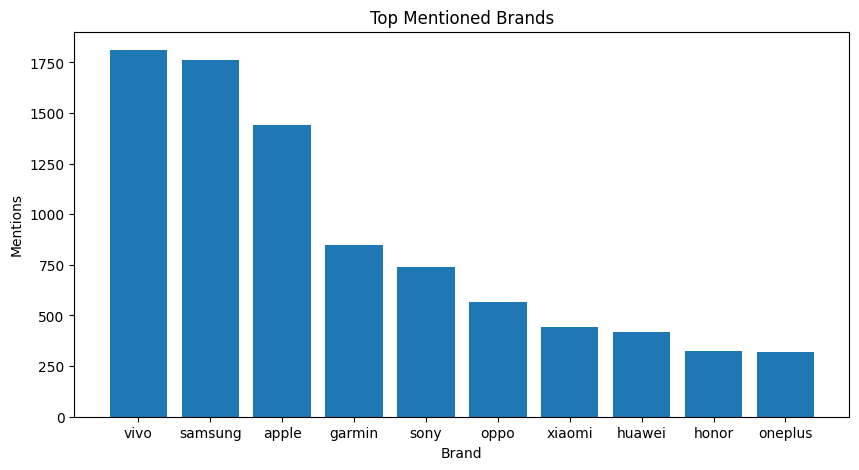

In [ ]:
import matplotlib.pyplot as plt

top_brands = brand_df.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_brands["brand"], top_brands["count"])

plt.title("Top Mentioned Brands")
plt.xlabel("Brand")
plt.ylabel("Mentions")

plt.show()

In [ ]:
brand_df.head(20)

,brand,count
0,vivo,1811
1,samsung,1762
2,apple,1439
3,garmin,850
4,sony,741
5,oppo,565
6,xiaomi,442
7,huawei,419
8,honor,325
9,oneplus,319


In [ ]:
# STEP 4: COMBINE AND EXPORT
# Brand and product dataframes are merged with a 'type' column distinguishing them.
# The combined entity_df is sorted by count and saved as named_entities.csv.
# This file is used for the NER section of the report and for reference
# when building product filter lists in the RAG pipeline.
entity_df.to_csv("named_entities.csv", index=False)

In [ ]:
brand_df = brand_df.rename(columns={"brand": "entity"})
product_df = product_df.rename(columns={"product": "entity"})

brand_df["type"] = "Brand"
product_df["type"] = "Product"

entity_df = pd.concat(
    [brand_df, product_df],
    ignore_index=True
)

entity_df = entity_df[["entity", "type", "count"]]

entity_df = entity_df.sort_values(
    by="count",
    ascending=False
)

entity_df.head(30)

,entity,type,count
0,vivo,Brand,1811
1,samsung,Brand,1762
2,apple,Brand,1439
16,iphone,Product,1010
3,garmin,Brand,850
4,sony,Brand,741
5,oppo,Brand,565
17,apple watch,Product,496
6,xiaomi,Brand,442
7,huawei,Brand,419


In [ ]:
from google.colab import files

files.download("named_entities.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
entity_df.sort_values("count", ascending=False).head(20)

,entity,type,count
0,vivo,Brand,1811
1,samsung,Brand,1762
2,apple,Brand,1439
16,iphone,Product,1010
3,garmin,Brand,850
4,sony,Brand,741
5,oppo,Brand,565
17,apple watch,Product,496
6,xiaomi,Brand,442
7,huawei,Brand,419


In [ ]:
print(product_df.head(20))

          product  count     type
0          iphone   1010  Product
1     apple watch    496  Product
2          galaxy    417  Product
3             xm5    386  Product
4   vivo x200 pro    345  Product
5           pixel    305  Product
6             xm4    292  Product
7             xm6    257  Product
8         airpods    212  Product
9            poco    187  Product
10      s24 ultra    185  Product
11            xm3    150  Product
12            cmf    139  Product
13    find x9 pro    138  Product
14       redmagic     92  Product
15  vivo x300 pro     82  Product
16      s25 ultra     79  Product
17          redmi     54  Product
18    find x8 pro     49  Product
